In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import sys
from pathlib import Path

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "training" / "data_utils.py").is_file()
)
sys.path.insert(0, str(repo_root / "src"))
from training.data_utils import canonical_legacy_track_id_split


In [2]:
og_df = pd.read_csv("../../../../data/SpotGenTrack/Data Sources/spotify_tracks.csv", index_col=0)
low_df = pd.read_csv("../../../../data/SpotGenTrack/Features Extracted/low_level_audio_features.csv", index_col=0)

df = pd.merge(
    low_df,
    og_df,
    left_on="track_id",
    right_on="id",
    how="inner"
)

In [3]:
target = "popularity"

drop_cols = [
    "track_id",
    "album_id",
    "analysis_url",
    "artists_id",
    "available_markets",
    "country",
    "href",
    "lyrics",
    "name",
    "playlist",
    "preview_url",
    "track_href",
    "track_name_prev",
    "type",
    "uri",
    "disc_number",
    "track_number"
]

df = df.drop(columns=drop_cols, errors="ignore")
df = df.dropna()
df = df.drop_duplicates()

In [4]:
target = "popularity"

track_ids = df["id"].astype(str)
X = df.drop(columns=[target, "id"])
y = df[target]

train_ids, validation_ids, test_ids = map(
    set, canonical_legacy_track_id_split()
)
train_mask = track_ids.isin(train_ids)
validation_mask = track_ids.isin(validation_ids)
test_mask = track_ids.isin(test_ids)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[validation_mask], y.loc[validation_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]


legacy deterministic random split train=71359, validation=15290, test=15290


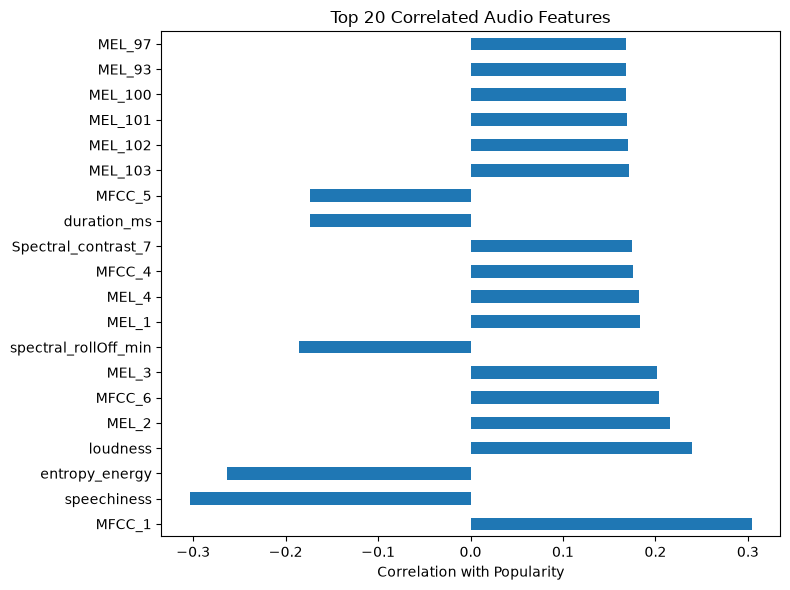

In [5]:
train_df = X_train.copy()
train_df[target] = y_train

correlations = (
    train_df.corr(numeric_only=True)[target]
    .drop(target)
)

correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

correlations.head(20).plot(kind="barh", figsize=(8,6))
plt.xlabel("Correlation with Popularity")
plt.title("Top 20 Correlated Audio Features")
plt.tight_layout()
plt.show()

In [6]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Train R2: {train_r2:.4f}")
print(f"Validation R2: {val_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

print(f"Train MAE: {train_mae:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Train R2: 0.3416
Validation R2: 0.2818
Test R2: 0.2919
Train RMSE: 13.6419
Validation RMSE: 14.2336
Test RMSE: 14.0362
Train MAE: 10.7991
Validation MAE: 11.3171
Test MAE: 11.1616
